# Wind Forecast Analysis

This notebook analyzes forecast accuracy for UK national wind generation.

Goals:
- Compare actual vs forecast wind generation
- Analyze forecast error
- Understand error vs horizon
- Estimate reliable wind power availability

## 1. Install Required Libraries

In [20]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 2. Load Actual Wind Generation Data

In [21]:
url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream"

params = {
    "settlementDateFrom": "2024-01-01",
    "settlementDateTo": "2024-01-10",
    "fuelType": "WIND",
    "format": "json"
}

response = requests.get(url, params=params)
actual_data = response.json()

actual_df = pd.DataFrame(actual_data)
actual_df.head()

,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
0,FUELHH,2024-01-11T00:00:00Z,2024-01-10T23:30:00Z,2024-01-10,48,WIND,6737
1,FUELHH,2024-01-10T23:30:00Z,2024-01-10T23:00:00Z,2024-01-10,47,WIND,6690
2,FUELHH,2024-01-10T23:00:00Z,2024-01-10T22:30:00Z,2024-01-10,46,WIND,6800
3,FUELHH,2024-01-10T22:30:00Z,2024-01-10T22:00:00Z,2024-01-10,45,WIND,6978
4,FUELHH,2024-01-10T22:00:00Z,2024-01-10T21:30:00Z,2024-01-10,44,WIND,7743


## 3. Load Forecast Dataset

In [22]:
forecast_url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream"

params = {
    "publishDateTimeFrom": "2024-01-01T00:00:00Z",
    "publishDateTimeTo": "2024-01-10T00:00:00Z",
    "format": "json"
}

response = requests.get(forecast_url, params=params)
forecast_data = response.json()

forecast_df = pd.DataFrame(forecast_data)
forecast_df.head()

,dataset,publishTime,startTime,generation
0,WINDFOR,2024-01-09T22:30:00Z,2024-01-09T21:00:00Z,8836
1,WINDFOR,2024-01-09T22:30:00Z,2024-01-09T22:00:00Z,8340
2,WINDFOR,2024-01-09T22:30:00Z,2024-01-09T23:00:00Z,7946
3,WINDFOR,2024-01-09T22:30:00Z,2024-01-10T00:00:00Z,7616
4,WINDFOR,2024-01-09T22:30:00Z,2024-01-10T01:00:00Z,7455


## 4. Data Cleaning

In [23]:
actual_df['startTime'] = pd.to_datetime(actual_df['startTime'])
forecast_df['startTime'] = pd.to_datetime(forecast_df['startTime'])
forecast_df['publishTime'] = pd.to_datetime(forecast_df['publishTime'])

## 5. Calculate Forecast Horizon

In [24]:
forecast_df['horizon_hours'] = (
    forecast_df['startTime'] - forecast_df['publishTime']
).dt.total_seconds() / 3600

Filter forecasts with horizon between 0 and 48 hours

In [25]:
forecast_df = forecast_df[
    (forecast_df['horizon_hours'] >= 0) &
    (forecast_df['horizon_hours'] <= 48)
]

## 6. Select Latest Forecast Per Target Time

In [26]:
forecast_df = forecast_df.sort_values('publishTime')
latest_forecast = forecast_df.groupby('startTime').last().reset_index()

## 7. Merge Actual and Forecast

In [27]:
merged_df = pd.merge(
    actual_df,
    latest_forecast,
    on='startTime',
    suffixes=('_actual','_forecast')
)

merged_df.head()

,dataset_actual,publishTime_actual,startTime,settlementDate,settlementPeriod,fuelType,generation_actual,dataset_forecast,publishTime_forecast,generation_forecast,horizon_hours
0,FUELHH,2024-01-10T23:30:00Z,2024-01-10 23:00:00+00:00,2024-01-10,47,WIND,6690,WINDFOR,2024-01-09 22:30:00+00:00,5250,24.5
1,FUELHH,2024-01-10T22:30:00Z,2024-01-10 22:00:00+00:00,2024-01-10,45,WIND,6978,WINDFOR,2024-01-09 22:30:00+00:00,5610,23.5
2,FUELHH,2024-01-10T21:30:00Z,2024-01-10 21:00:00+00:00,2024-01-10,43,WIND,8234,WINDFOR,2024-01-09 22:30:00+00:00,6256,22.5
3,FUELHH,2024-01-10T20:30:00Z,2024-01-10 20:00:00+00:00,2024-01-10,41,WIND,8785,WINDFOR,2024-01-09 22:30:00+00:00,6790,21.5
4,FUELHH,2024-01-10T19:30:00Z,2024-01-10 19:00:00+00:00,2024-01-10,39,WIND,8831,WINDFOR,2024-01-09 22:30:00+00:00,7257,20.5


## 8. Forecast Error Calculation

In [28]:
merged_df['error'] = merged_df['generation_forecast'] - merged_df['generation_actual']
merged_df['absolute_error'] = merged_df['error'].abs()

merged_df[['generation_actual','generation_forecast','absolute_error']].head()

,generation_actual,generation_forecast,absolute_error
0,6690,5250,1440
1,6978,5610,1368
2,8234,6256,1978
3,8785,6790,1995
4,8831,7257,1574


## 9. Error Statistics

In [29]:
merged_df['absolute_error'].describe()

count     219.000000
mean     1178.429224
std       856.386262
min         3.000000
25%       421.000000
50%      1097.000000
75%      1841.000000
max      3237.000000
Name: absolute_error, dtype: float64

## 10. Error Distribution

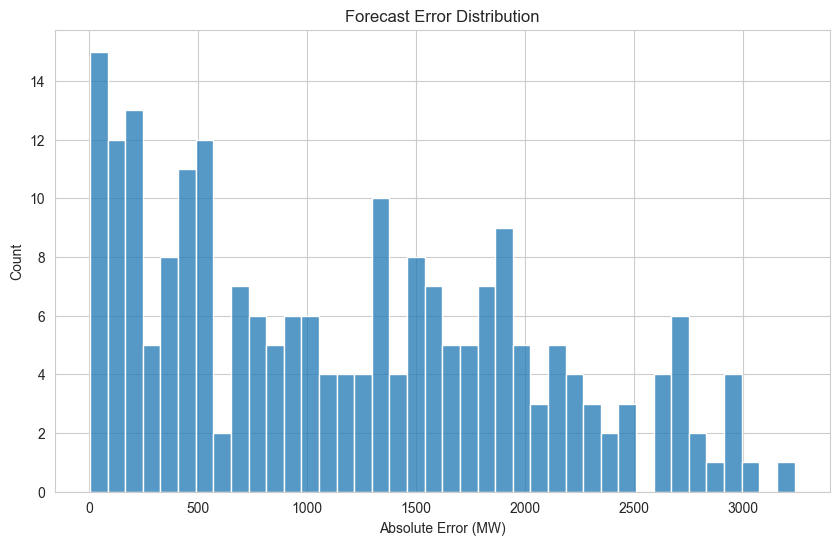

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(merged_df['absolute_error'], bins=40)
plt.title("Forecast Error Distribution")
plt.xlabel("Absolute Error (MW)")
plt.show()

## 11. Error by Time of Day

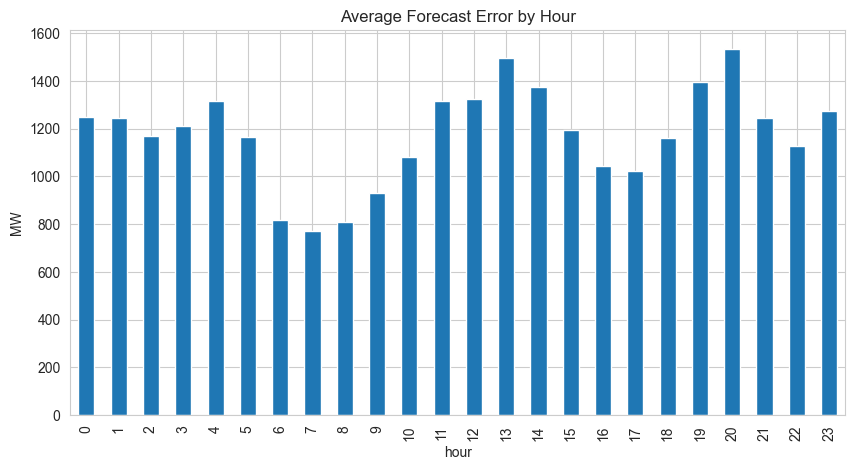

In [31]:
merged_df['hour'] = merged_df['startTime'].dt.hour

hourly_error = merged_df.groupby('hour')['absolute_error'].mean()

hourly_error.plot(kind='bar', figsize=(10,5))
plt.title("Average Forecast Error by Hour")
plt.ylabel("MW")
plt.show()

## 12. Wind Generation Distribution

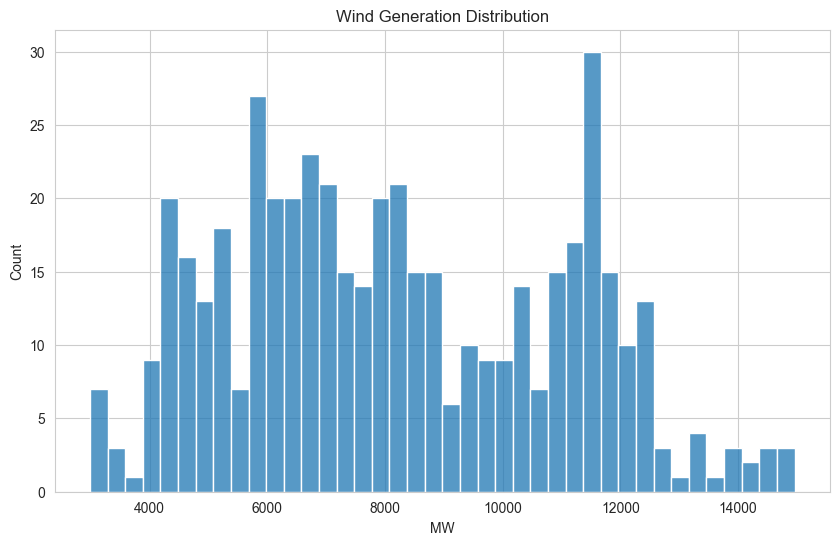

In [32]:
plt.figure(figsize=(10,6))
sns.histplot(actual_df['generation'], bins=40)
plt.title("Wind Generation Distribution")
plt.xlabel("MW")
plt.show()

## 13. Reliable Wind Capacity Estimation

In [33]:
p10 = actual_df['generation'].quantile(0.10)
p20 = actual_df['generation'].quantile(0.20)

print("P10 Wind Generation:", p10)
print("P20 Wind Generation:", p20)

P10 Wind Generation: 4666.900000000001
P20 Wind Generation: 5711.2


## 14. Recommendation

Based on historical wind generation data:

- The 10th percentile represents the minimum generation available 90% of the time.
- This value can be used as a conservative estimate of reliable wind power.

System operators can rely on approximately **P10 MW** of wind generation to meet electricity demand under most conditions.